# Community Alignment — RLHF distortion analysis on PCA features

Ports `empirics_moralmachine.ipynb` to the Community Alignment dataset using the embedding-PCA features built in `final_layer.ipynb`.

**Mapping from MM → CA**

| Moral Machine                          | Community Alignment                                            |
|----------------------------------------|----------------------------------------------------------------|
| `UserID`                               | `annotator_id`                                                 |
| 20-dim character columns               | 32-dim PCA features `pca1..pca32` of (prompt + response)       |
| α_z = chars(saved) − chars(not_saved)  | α_z = pca(preferred) − pca(other), one per non-preferred sib   |
| 1 pairwise observation per scenario    | 3 pairwise observations per (annotator, choice_set)            |
| `Saved = 1` (label always 1)           | `y = 1` (label always 1; `_make_two_class` half-flip applies)  |

Once α / `UserID` are built, the rest of the MM pipeline (per-user BTL → k-means → cluster BTL → pooled BTL → welfare + alignment externalities) drops in unchanged.

## Imports + config

In [77]:
from __future__ import annotations
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit as sigmoid
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

# --- config ---
CAND_PATH      = Path("candidates_with_pca.parquet")
FEATURE_COLS   = [f"pca{i+1}" for i in range(32)]
K_CLUSTERS     = 8
MIN_OBS_USER   = 15            # ~45 obs/user (3 per set × ~15 sets/user)
BTL_C          = 500.0         # weak regularization. Per-user fits have ~45 obs in 32 dim;
                               # at C=5 they get heavily shrunk so ||θ̄|| << ||θ̂|| and the social-
                               # welfare invariant breaks (RLHF appears to beat utilitarian).
                               # C=500 leaves per-user fits near-unregularized so ||θ̄|| ≈ ||θ̂||.
                               # Pooled BTL (~38k obs) is unregularized at either C value.
OUTLIER_PCT    = 95            # drop users with ||θ_n|| above this percentile
RANDOM_STATE   = 0

print(f"features: {len(FEATURE_COLS)} dims  | clusters: k={K_CLUSTERS}  | BTL_C={BTL_C}")

features: 32 dims  | clusters: k=8  | BTL_C=500.0


## 1. Load candidate-level PCA table

In [78]:
cand = pd.read_parquet(CAND_PATH)
print(f"loaded: {cand.shape[0]:,} rows x {cand.shape[1]} cols")

needed = ["annotator_id", "choice_set_id", "candidate_letter", "is_preferred"] + FEATURE_COLS
missing = [c for c in needed if c not in cand.columns]
if missing:
    raise ValueError(f"missing columns: {missing}")

# Drop sets where the preferred-count != 1 (data hygiene)
set_pref = cand.groupby(["annotator_id", "choice_set_id"])["is_preferred"].sum()
good = set(set_pref[set_pref == 1].index)
before = cand[["annotator_id", "choice_set_id"]].drop_duplicates().shape[0]
cand = cand.set_index(["annotator_id", "choice_set_id"]).loc[list(good)].reset_index()
after = cand[["annotator_id", "choice_set_id"]].drop_duplicates().shape[0]
print(f"clean (annotator, set) groups: {after:,} / {before:,}  (dropped {before - after})")

loaded: 56,924 rows x 48 cols
clean (annotator, set) groups: 14,221 / 14,226  (dropped 5)


## 2. Build pairwise α dataset

For each (annotator, choice_set), let $p$ be the preferred candidate and $o$ each other candidate. Emit 3 rows of

$$\alpha_z = \text{pca}(p) - \text{pca}(o), \quad y = 1$$

This is the BTL-equivalent pairwise comparison: "this annotator preferred $p$ over $o$".

(Equivalent to `build_alpha_vectors` in MM — except instead of looking up the saved/not-saved row by `ResponseID`, we contrast the preferred PCA vector against each of the 3 sibling candidates.)

In [79]:
def build_pairwise_alpha(cand: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    """
    cand: candidate-level table (4 rows per (annotator, set))
    Returns: long-format pairwise table with cols
        annotator_id, choice_set_id, preferred_letter, other_letter, <feature_cols>
    """
    pref = cand[cand["is_preferred"] == 1].copy()
    oth  = cand[cand["is_preferred"] == 0].copy()

    pref = pref.set_index(["annotator_id", "choice_set_id"])
    oth  = oth.set_index(["annotator_id", "choice_set_id"])

    pref_feats = pref[feature_cols]
    pref_letter = pref["candidate_letter"].rename("preferred_letter")

    # broadcast preferred features against each non-preferred sibling within the same group
    joined = oth[["candidate_letter"] + feature_cols].join(
        pref_feats, how="inner", lsuffix="_o", rsuffix="_p"
    ).join(pref_letter, how="inner")

    o_cols = [f"{c}_o" for c in feature_cols]
    p_cols = [f"{c}_p" for c in feature_cols]
    diff = joined[p_cols].to_numpy() - joined[o_cols].to_numpy()

    out = pd.DataFrame(diff, columns=feature_cols, index=joined.index)
    out["preferred_letter"] = joined["preferred_letter"].values
    out["other_letter"]     = joined["candidate_letter"].values
    return out.reset_index()

alpha_df = build_pairwise_alpha(cand, FEATURE_COLS)
alpha_df["UserID"] = alpha_df["annotator_id"]
print(f"pairwise rows : {len(alpha_df):,}  (expect ~3 × clean groups)")
print(f"users         : {alpha_df['UserID'].nunique():,}")
print()
print(alpha_df[FEATURE_COLS].describe().iloc[:, :6].round(4).T)

pairwise rows : 42,663  (expect ~3 × clean groups)
users         : 1,069

        count    mean     std     min     25%     50%     75%     max
pca1  42663.0  0.0061  0.0502 -0.4128 -0.0185  0.0035  0.0285  0.4128
pca2  42663.0 -0.0020  0.0543 -0.4755 -0.0301 -0.0010  0.0266  0.4276
pca3  42663.0  0.0074  0.0583 -0.2656 -0.0267  0.0066  0.0398  0.2656
pca4  42663.0  0.0030  0.0503 -0.2489 -0.0258  0.0033  0.0313  0.2489
pca5  42663.0 -0.0057  0.0681 -0.3744 -0.0436 -0.0053  0.0341  0.2970
pca6  42663.0  0.0026  0.0501 -0.2254 -0.0251  0.0020  0.0293  0.2533


## 3. Per-user BTL fit

Identical to MM `fit_per_user_btl`: random-half-flip to two-class, then regularized logistic regression with no intercept. Fits θ_n in 32-dim PCA space.

In [80]:
def _make_two_class(X, seed=0):
    """BTL all-positive (X, y=1) → balanced two-class via random half-flip."""
    rng = np.random.default_rng(seed)
    flip = rng.random(len(X)) < 0.5
    X_out = X.copy()
    X_out[flip] *= -1
    y_out = np.ones(len(X))
    y_out[flip] = 0
    return X_out, y_out


def fit_per_user_btl(alpha_df, feature_cols, C=BTL_C, min_obs=MIN_OBS_USER):
    user_ids_out, thetas = [], []
    grouped = alpha_df.groupby("UserID")
    n_skipped = 0
    for i, (uid, grp) in enumerate(grouped):
        if len(grp) < min_obs:
            n_skipped += 1
            continue
        X = grp[feature_cols].to_numpy().astype(float)
        if X.std() < 1e-10:
            n_skipped += 1
            continue
        X_flip, y_flip = _make_two_class(X, seed=i)
        lr = LogisticRegression(fit_intercept=False, C=C, solver="lbfgs",
                                max_iter=2000, tol=1e-6)
        lr.fit(X_flip, y_flip)
        user_ids_out.append(uid)
        thetas.append(lr.coef_.ravel())
        if (i + 1) % 200 == 0:
            print(f"  fit {i + 1}/{len(grouped)} users")
    print(f"  done: {len(user_ids_out)} fit, {n_skipped} skipped (< {min_obs} obs / degenerate)")
    return np.array(user_ids_out), np.vstack(thetas)

user_ids, profiles = fit_per_user_btl(alpha_df, FEATURE_COLS)
print(f"profiles: {profiles.shape}")

  fit 400/1069 users
  fit 600/1069 users
  fit 800/1069 users
  fit 1000/1069 users
  done: 878 fit, 191 skipped (< 15 obs / degenerate)
profiles: (878, 32)


In [81]:
# Outlier filter: drop top OUTLIER_PCT %ile by ||θ|| (likely fits with too few obs)
norms = np.linalg.norm(profiles, axis=1)
cutoff = np.percentile(norms, OUTLIER_PCT)
keep = norms <= cutoff
print(f"||θ|| stats: median={np.median(norms):.2f}  mean={norms.mean():.2f}  "
      f"p95={cutoff:.2f}  max={norms.max():.2f}")
print(f"keeping {keep.sum()} / {len(keep)} users (drop ||θ|| > {cutoff:.2f})")
user_ids = user_ids[keep]
profiles = profiles[keep]

||θ|| stats: median=60.57  mean=58.38  p95=72.06  max=81.87
keeping 834 / 878 users (drop ||θ|| > 72.06)


## 4. Cluster users (k-means on standardized profiles)

In [82]:
def cluster_users(profiles, k, feature_cols, seed=42):
    scaler = StandardScaler()
    X = scaler.fit_transform(profiles)
    km = KMeans(n_clusters=k, n_init=20, random_state=seed)
    labels = km.fit_predict(X)
    centroid_df = pd.DataFrame(
        [profiles[labels == g].mean(axis=0) for g in range(k)],
        columns=feature_cols,
    )
    centroid_df.index.name = "cluster"
    return labels, centroid_df

labels, centroid_df = cluster_users(profiles, K_CLUSTERS, FEATURE_COLS)
print(f"\ncluster sizes (k={K_CLUSTERS}):")
for g in range(K_CLUSTERS):
    n = (labels == g).sum()
    avg_norm = np.linalg.norm(profiles[labels == g], axis=1).mean()
    print(f"  cluster {g}: {n:,} users ({n / len(labels) * 100:.1f}%)  avg ||θ||={avg_norm:.2f}")


cluster sizes (k=8):
  cluster 0: 82 users (9.8%)  avg ||θ||=61.10
  cluster 1: 96 users (11.5%)  avg ||θ||=56.33
  cluster 2: 82 users (9.8%)  avg ||θ||=59.23
  cluster 3: 118 users (14.1%)  avg ||θ||=55.97
  cluster 4: 145 users (17.4%)  avg ||θ||=53.80
  cluster 5: 99 users (11.9%)  avg ||θ||=58.27
  cluster 6: 106 users (12.7%)  avg ||θ||=58.85
  cluster 7: 106 users (12.7%)  avg ||θ||=59.35


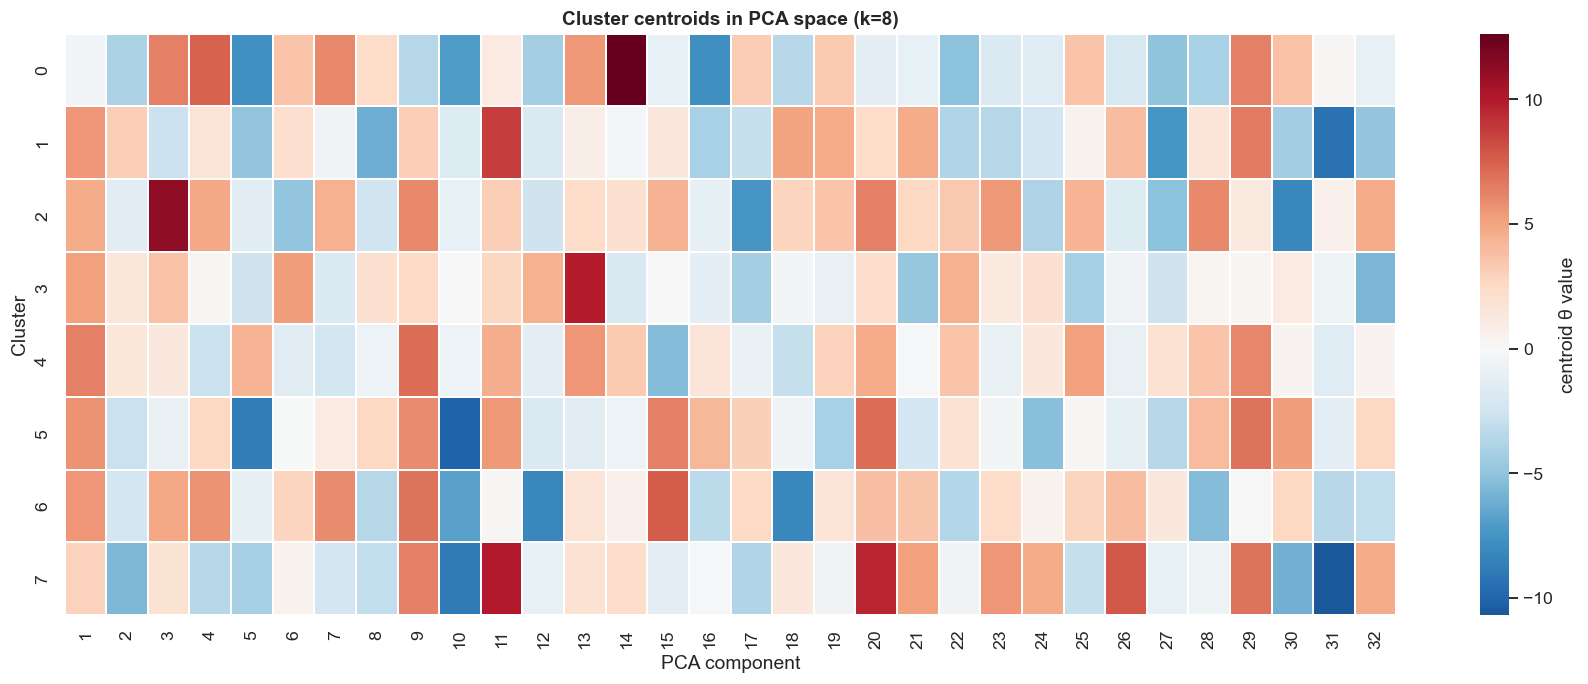

In [83]:
# Centroid heatmap on PCA dims (less interpretable than MM's named characters,
# but still shows which directions in embedding space each cluster pulls toward)
fig, ax = plt.subplots(figsize=(16, max(3, K_CLUSTERS * 0.8)))
sns.heatmap(centroid_df, annot=False, cmap="RdBu_r", center=0,
            linewidths=0.3, ax=ax, cbar_kws={"label": "centroid θ value"})
ax.set_title(f"Cluster centroids in PCA space (k={K_CLUSTERS})", fontweight="bold")
ax.set_xlabel("PCA component")
ax.set_ylabel("Cluster")
ax.set_xticklabels([f"{i + 1}" for i in range(len(FEATURE_COLS))])
plt.tight_layout()
plt.show()

In [84]:
# Demographic mix per cluster (helps interpret what k-means picked up)
ann_meta = (cand.drop_duplicates("annotator_id")
                .set_index("annotator_id")
                [["annotator_country", "annotator_gender", "annotator_political"]])
user_clu = pd.DataFrame({"annotator_id": user_ids, "cluster": labels}).set_index("annotator_id")
user_clu = user_clu.join(ann_meta, how="left")

for col in ["annotator_country", "annotator_gender", "annotator_political"]:
    print(f"\n=== {col} share by cluster (top 5 levels) ===")
    tbl = (user_clu.groupby("cluster")[col].value_counts(normalize=True)
                   .unstack(fill_value=0))
    top = tbl.sum().sort_values(ascending=False).head(5).index
    print(tbl[top].round(3))


=== annotator_country share by cluster (top 5 levels) ===
annotator_country  india  united states  brazil  italy  france
cluster                                                       
0                  0.707          0.134   0.061  0.037   0.061
1                  0.198          0.156   0.323  0.135   0.188
2                  0.293          0.317   0.146  0.085   0.159
3                  0.246          0.229   0.136  0.297   0.093
4                  0.172          0.186   0.207  0.290   0.145
5                  0.323          0.434   0.081  0.071   0.091
6                  0.453          0.340   0.094  0.066   0.047
7                  0.179          0.406   0.189  0.028   0.198

=== annotator_gender share by cluster (top 5 levels) ===
annotator_gender   male  female  other
cluster                               
0                 0.679   0.321  0.000
1                 0.750   0.250  0.000
2                 0.612   0.388  0.000
3                 0.615   0.385  0.000
4                 0

## 5. BTL fits: per-cluster θ_g, pooled θ̂, utilitarian θ̄

In [85]:
def build_btl_data(alpha_df, user_ids, labels, feature_cols, max_obs=500_000):
    user_to_cluster = dict(zip(user_ids, labels))
    df = alpha_df.copy()
    df["cluster"] = df["UserID"].map(user_to_cluster)
    df = df.dropna(subset=["cluster"])
    df["cluster"] = df["cluster"].astype(int)
    if len(df) > max_obs:
        df = df.sample(max_obs, random_state=42)
    alpha = df[feature_cols].to_numpy().astype(float)
    y     = np.ones(len(alpha))
    group = df["cluster"].to_numpy()
    sizes = {g: int((group == g).sum()) for g in sorted(np.unique(group))}
    return alpha, y, group, sizes


def fit_btl(alpha, y, C=BTL_C):
    X, y2 = _make_two_class(alpha)
    lr = LogisticRegression(fit_intercept=False, C=C, solver="lbfgs",
                            max_iter=2000, tol=1e-8)
    lr.fit(X, y2)
    return lr.coef_.ravel()


def fit_all_models(alpha, y, group, n_clusters, user_profiles=None):
    theta_groups = []
    for g in range(n_clusters):
        mask = group == g
        th = fit_btl(alpha[mask], y[mask])
        theta_groups.append(th)
        print(f"  θ_{g}: ||θ||={np.linalg.norm(th):.3f}  ({mask.sum():,} obs)")
    theta_hat = fit_btl(alpha, y)
    print(f"  θ̂ (pooled): ||θ||={np.linalg.norm(theta_hat):.3f}  ({len(y):,} obs)")
    weights = np.array([(group == g).mean() for g in range(n_clusters)])
    if user_profiles is not None:
        theta_bar = user_profiles.mean(axis=0)
        print(f"  θ̄ (utilitarian, individual θ_n mean): ||θ||={np.linalg.norm(theta_bar):.3f}")
    else:
        theta_bar = sum(w * th for w, th in zip(weights, theta_groups))
    print(f"  ||θ̂ − θ̄|| = {np.linalg.norm(theta_hat - theta_bar):.4f}")
    return theta_groups, theta_hat, theta_bar, weights


print("build_btl_data")
alpha_arr, y_arr, group_arr, group_sizes = build_btl_data(alpha_df, user_ids, labels, FEATURE_COLS)
print(f"  group sizes: {group_sizes}")

print("\nfit_all_models")
theta_groups, theta_hat, theta_bar, group_weights = fit_all_models(
    alpha_arr, y_arr, group_arr, K_CLUSTERS, user_profiles=profiles
)

build_btl_data
  group sizes: {0: 3822, 1: 4440, 2: 3993, 3: 5064, 4: 6015, 5: 4671, 6: 4779, 7: 5475}

fit_all_models
  θ_0: ||θ||=30.276  (3,822 obs)
  θ_1: ||θ||=25.067  (4,440 obs)
  θ_2: ||θ||=22.333  (3,993 obs)
  θ_3: ||θ||=18.488  (5,064 obs)
  θ_4: ||θ||=20.816  (6,015 obs)
  θ_5: ||θ||=19.960  (4,671 obs)
  θ_6: ||θ||=22.202  (4,779 obs)
  θ_7: ||θ||=25.568  (5,475 obs)
  θ̂ (pooled): ||θ||=12.462  (38,259 obs)
  θ̄ (utilitarian, individual θ_n mean): ||θ||=13.804
  ||θ̂ − θ̄|| = 4.1549


In [86]:
# Four pooled / utilitarian thetas, same construction as MM
theta_pop_util  = profiles.mean(axis=0)
theta_clust_unw = np.mean(theta_groups, axis=0)
theta_clust_wt  = sum(w * th for w, th in zip(group_weights, theta_groups))
theta_pooled    = theta_hat

rows = [
    {"vector": "θ_pop_util  (full-pop utilitarian)",    **dict(zip(FEATURE_COLS, theta_pop_util))},
    {"vector": "θ_clust_unw (unweighted cluster mean)", **dict(zip(FEATURE_COLS, theta_clust_unw))},
    {"vector": "θ_clust_wt  (weighted cluster mean)",   **dict(zip(FEATURE_COLS, theta_clust_wt))},
    {"vector": "θ_pooled    (full pooled RLHF)",        **dict(zip(FEATURE_COLS, theta_pooled))},
]
for g, th in enumerate(theta_groups):
    rows.append({"vector": f"θ_{g}          (cluster {g})", **dict(zip(FEATURE_COLS, th))})
theta_df = pd.DataFrame(rows).set_index("vector")
print(theta_df.iloc[:, :8].round(4).to_string())

                                         pca1    pca2    pca3     pca4    pca5    pca6    pca7    pca8
vector                                                                                                
θ_pop_util  (full-pop utilitarian)     4.6561 -1.0136  2.8988   1.5079 -2.7968  1.0379  0.8947 -1.1294
θ_clust_unw (unweighted cluster mean)  4.4409 -0.5051  2.5518   2.0922 -1.9676 -0.4670  1.1022 -1.0223
θ_clust_wt  (weighted cluster mean)    4.7360 -0.2939  2.3294   1.5949 -1.6938 -0.5026  0.7725 -1.1422
θ_pooled    (full pooled RLHF)         4.0844  0.4401  1.8961   0.7180 -1.1121 -0.4788  0.2172 -1.4405
θ_0          (cluster 0)              -1.3729 -5.7165  6.1324  11.2338 -6.2534  1.6639  5.1903  4.7896
θ_1          (cluster 1)               4.6713  4.3671 -2.6650  -0.6037 -3.9755 -1.0498 -0.1490 -4.8512
θ_2          (cluster 2)               3.7421 -2.3579  7.5949   3.3809 -0.5000 -4.9258  3.9884 -2.5055
θ_3          (cluster 3)               5.6340  2.5743  3.1401   0.0247 -1

## 6. Welfare and alignment externality

Same expressions as MM — eq. 6 (welfare) and eq. 16/17 (Γ, η). The deployment query distribution `q_dep` is set to `empirical` (subsample of training α). The MM "uniform over 190 character pairs" doesn't translate to PCA features, so we also include a `bootstrap` option that resamples α with replacement.

In [87]:
def compute_welfare_and_externalities(alpha, group, theta_groups, theta_hat,
                                      theta_bar, weights, user_labels=None,
                                      n_deploy=10_000, seed=42, q_dep="empirical"):
    rng = np.random.default_rng(seed)
    k_dim = alpha.shape[1]
    n_clusters = len(theta_groups)
    theta_bar_clust = sum(w * th for w, th in zip(weights, theta_groups))
    print(f"  ||θ̄_clust|| = {np.linalg.norm(theta_bar_clust):.4f}  "
          f"||θ̂|| = {np.linalg.norm(theta_hat):.4f}")

    if q_dep == "empirical":
        idx = rng.choice(len(alpha), size=min(n_deploy, len(alpha)), replace=False)
        alpha_dep = alpha[idx]
        qlabel = "empirical (subsample of training)"
    elif q_dep == "bootstrap":
        idx = rng.choice(len(alpha), size=n_deploy, replace=True)
        alpha_dep = alpha[idx]
        qlabel = f"bootstrap ({n_deploy} resamples)"
    else:
        alpha_dep = np.asarray(q_dep)
        qlabel = f"custom ({len(alpha_dep)})"
    print(f"  q_dep: {qlabel}")

    sigma_hat_dep = sigmoid(alpha_dep @ theta_hat)
    v_hat_dep     = sigma_hat_dep * (1 - sigma_hat_dep)
    sigma_opt_dep = sigmoid(alpha_dep @ theta_bar_clust)

    rows = []
    for g in range(n_clusters):
        logits_g = alpha_dep @ theta_groups[g]
        w_ideal = 0.5 * np.abs(logits_g).mean()
        w_opt   = (logits_g * (sigma_opt_dep - 0.5)).mean()
        w_rlhf  = (logits_g * (sigma_hat_dep - 0.5)).mean()
        rows.append({
            "group": g, "weight": weights[g],
            "W_ideal": w_ideal, "W_opt": w_opt, "W_rlhf": w_rlhf,
            "rlhf_ratio":  w_rlhf / w_opt   if abs(w_opt)   > 1e-10 else np.nan,
            "total_ratio": w_rlhf / w_ideal if abs(w_ideal) > 1e-10 else np.nan,
        })
    welfare_df = pd.DataFrame(rows)

    sigma_hat_train = sigmoid(alpha @ theta_hat)
    v_hat_train     = sigma_hat_train * (1 - sigma_hat_train)
    J     = (alpha * v_hat_train[:, None]).T @ alpha / len(alpha)
    J_inv = np.linalg.inv(J + 1e-6 * np.eye(k_dim))

    welfare_grad = ((alpha_dep * ((alpha_dep @ theta_bar_clust) * v_hat_dep)[:, None])
                    .mean(axis=0))
    eta = J_inv @ welfare_grad

    alpha_dot_eta = alpha_dep @ eta
    gamma_mat = np.column_stack([
        (sigmoid(alpha_dep @ theta_groups[g]) - sigma_hat_dep) * alpha_dot_eta
        for g in range(n_clusters)
    ])
    gamma_df = pd.DataFrame(gamma_mat, columns=[f"g={g}" for g in range(n_clusters)])

    N = len(alpha)
    p_hat = np.array([(group == g).sum() / N for g in range(n_clusters)])
    if user_labels is not None:
        p_star = np.array([(user_labels == g).sum() / len(user_labels)
                           for g in range(n_clusters)])
    else:
        p_star = np.ones(n_clusters) / n_clusters
    print(f"  p̂ = {np.round(p_hat, 3)}")
    print(f"  p* = {np.round(p_star, 3)}")
    print(f"  excess (p̂ − p*) = {np.round(p_hat - p_star, 4)}")

    return {
        "welfare_df": welfare_df, "gamma_df": gamma_df,
        "J_inv": J_inv, "eta": eta,
        "alpha_dep": alpha_dep, "sigma_hat_dep": sigma_hat_dep,
        "qdep_label": qlabel, "theta_bar_clust": theta_bar_clust,
        "p_hat": p_hat, "p_star": p_star,
    }

results = {}
for q in ["empirical", "bootstrap"]:
    print(f"\n── q_dep = {q} ──")
    results[q] = compute_welfare_and_externalities(
        alpha_arr, group_arr, theta_groups, theta_hat, theta_bar, group_weights,
        user_labels=labels, q_dep=q,
    )
ext = results["empirical"]

print("\n── Welfare table (empirical q_dep) ──")
print(ext["welfare_df"].round(4).to_string(index=False))


── q_dep = empirical ──
  ||θ̄_clust|| = 13.5406  ||θ̂|| = 12.4616
  q_dep: empirical (subsample of training)
  p̂ = [0.1   0.116 0.104 0.132 0.157 0.122 0.125 0.143]
  p* = [0.098 0.115 0.098 0.141 0.174 0.119 0.127 0.127]
  excess (p̂ − p*) = [ 0.0016  0.0009  0.006  -0.0091 -0.0166  0.0034 -0.0022  0.016 ]

── q_dep = bootstrap ──
  ||θ̄_clust|| = 13.5406  ||θ̂|| = 12.4616
  q_dep: bootstrap (10000 resamples)
  p̂ = [0.1   0.116 0.104 0.132 0.157 0.122 0.125 0.143]
  p* = [0.098 0.115 0.098 0.141 0.174 0.119 0.127 0.127]
  excess (p̂ − p*) = [ 0.0016  0.0009  0.006  -0.0091 -0.0166  0.0034 -0.0022  0.016 ]

── Welfare table (empirical q_dep) ──
 group  weight  W_ideal  W_opt  W_rlhf  rlhf_ratio  total_ratio
     0  0.0999   1.2788 0.3905  0.3212      0.8226       0.2512
     1  0.1161   1.0184 0.4156  0.3942      0.9484       0.3871
     2  0.1044   0.9929 0.3813  0.3600      0.9441       0.3626
     3  0.1324   0.7848 0.2712  0.2647      0.9760       0.3372
     4  0.1572   0.8073

## 7. Diagnostic plots

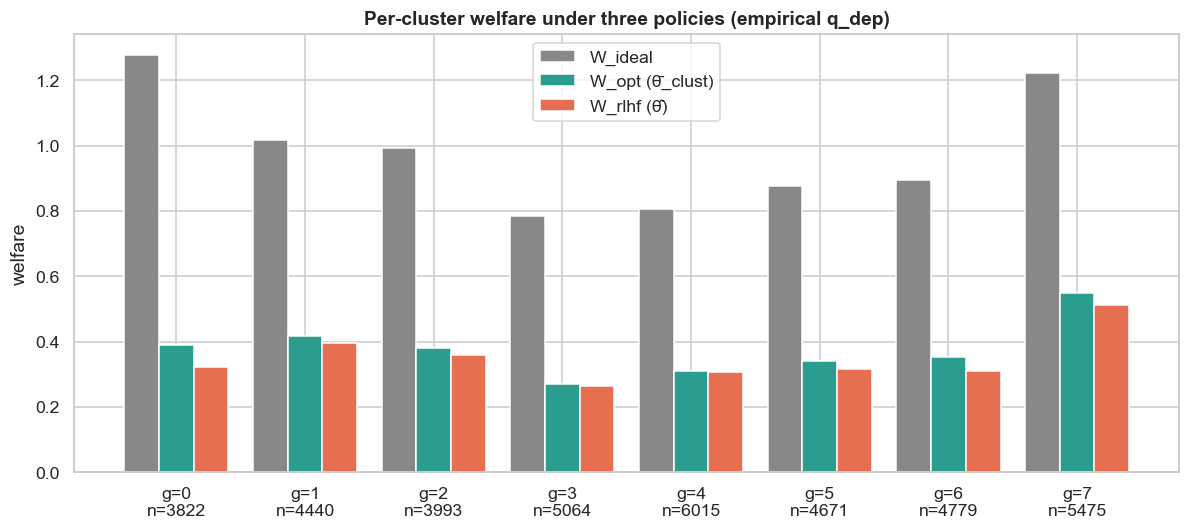

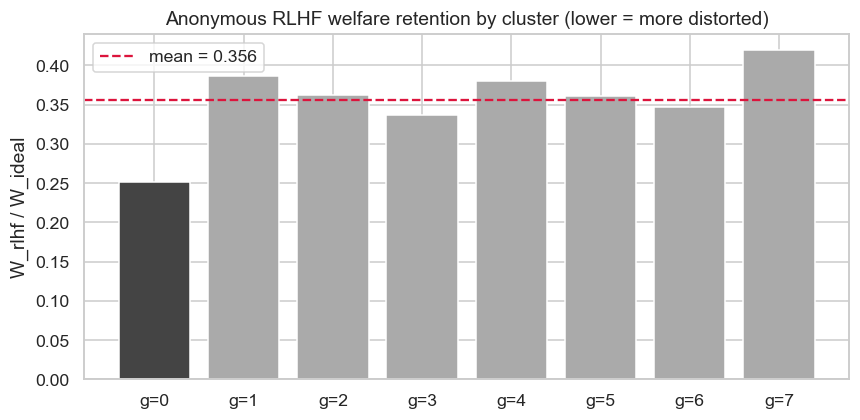

In [88]:
# Welfare bar chart per cluster
wdf = ext["welfare_df"].copy()
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(wdf))
w = 0.27
ax.bar(x - w, wdf["W_ideal"], width=w, label="W_ideal", color="#888")
ax.bar(x,       wdf["W_opt"],   width=w, label="W_opt (θ̄_clust)", color="#2a9d8f")
ax.bar(x + w,   wdf["W_rlhf"],  width=w, label="W_rlhf (θ̂)", color="#e76f51")
ax.set_xticks(x)
ax.set_xticklabels([f"g={g}\nn={int(group_sizes[g])}" for g in wdf["group"]])
ax.set_ylabel("welfare")
ax.set_title("Per-cluster welfare under three policies (empirical q_dep)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# Total ratio per cluster (RLHF welfare / ideal welfare)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x, wdf["total_ratio"], color=["#444" if g == wdf["total_ratio"].idxmin() else "#aaa" for g in x])
ax.axhline(wdf["total_ratio"].mean(), ls="--", color="crimson", label=f"mean = {wdf['total_ratio'].mean():.3f}")
ax.set_xticks(x)
ax.set_xticklabels([f"g={g}" for g in wdf["group"]])
ax.set_ylabel("W_rlhf / W_ideal")
ax.set_title("Anonymous RLHF welfare retention by cluster (lower = more distorted)")
ax.legend()
plt.tight_layout()
plt.show()

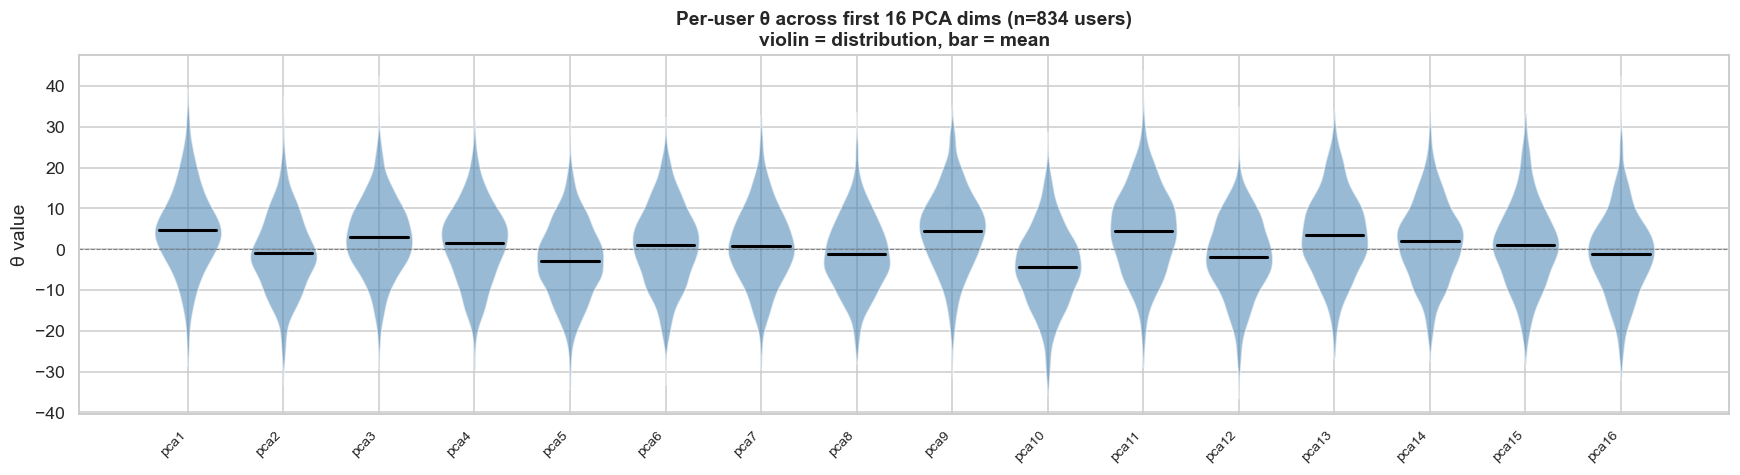

In [89]:
# Violin plot: per-user θ across PCA dims (only first 16 to stay readable)
n_show = 16
fig, ax = plt.subplots(figsize=(16, 4.5))
data = [profiles[:, i] for i in range(n_show)]
parts = ax.violinplot(data, positions=range(n_show), showmedians=False, showextrema=False, widths=0.7)
for pc in parts["bodies"]:
    pc.set_facecolor("steelblue")
    pc.set_alpha(0.55)
means = profiles.mean(axis=0)
for i in range(n_show):
    ax.plot([i - 0.3, i + 0.3], [means[i], means[i]], color="black", lw=2)
ax.axhline(0, color="grey", ls="--", lw=0.7)
ax.set_xticks(range(n_show))
ax.set_xticklabels([f"pca{i + 1}" for i in range(n_show)], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("θ value")
ax.set_title(f"Per-user θ across first {n_show} PCA dims (n={len(profiles):,} users)\nviolin = distribution, bar = mean",
             fontweight="bold")
plt.tight_layout()
plt.show()

In [90]:
# Top alignment-externality test queries: largest |Γ_{g,z}| within the empirical α set
gamma = ext["gamma_df"].abs().sum(axis=1).sort_values(ascending=False)
top_idx = gamma.head(10).index.to_numpy()
ad = ext["alpha_dep"][top_idx]

rows = []
for i, qi in enumerate(top_idx):
    rows.append({
        "rank": i + 1,
        "|Γ| sum": gamma.iloc[i],
        "α·η": float(ad[i] @ ext["eta"]),
        "σ(α·θ̂)": float(sigmoid(ad[i] @ theta_hat)),
        **{f"Γ_{g}": float(ext["gamma_df"].iloc[qi, g]) for g in range(K_CLUSTERS)},
    })
print("top-10 alignment-externality queries (by Σ_g |Γ_{g,z}|):")
print(pd.DataFrame(rows).round(4).to_string(index=False))

top-10 alignment-externality queries (by Σ_g |Γ_{g,z}|):
 rank  |Γ| sum     α·η  σ(α·θ̂)     Γ_0     Γ_1     Γ_2     Γ_3     Γ_4     Γ_5     Γ_6    Γ_7
    1   3.6006  3.9883   0.9829 -2.6267  0.0573  0.0328 -0.0218  0.0551 -0.2132 -0.5323 0.0614
    2   3.3661  2.1804   0.9084 -1.6891  0.1680 -0.0589 -0.2734  0.0648  0.0380 -0.8868 0.1872
    3   3.3661  2.1804   0.9084 -1.6891  0.1680 -0.0589 -0.2734  0.0648  0.0380 -0.8868 0.1872
    4   3.3661 -2.1804   0.0916 -1.6891  0.1680 -0.0589 -0.2734  0.0648  0.0380 -0.8868 0.1872
    5   3.3661 -2.1804   0.0916 -1.6891  0.1680 -0.0589 -0.2734  0.0648  0.0380 -0.8868 0.1872
    6   3.2149  1.8822   0.7906  0.3853 -0.1705 -0.6482 -0.4755 -0.6270  0.2339  0.3015 0.3730
    7   3.2149  1.8822   0.7906  0.3853 -0.1705 -0.6482 -0.4755 -0.6270  0.2339  0.3015 0.3730
    8   3.2149 -1.8822   0.2094  0.3853 -0.1705 -0.6482 -0.4755 -0.6270  0.2339  0.3015 0.3730
    9   3.2149 -1.8822   0.2094  0.3853 -0.1705 -0.6482 -0.4755 -0.6270  0.2339  0.3015 

## 8. Mechanism comparison: utilitarian, RLHF, strategyproof

Port of the kidney distortion charts to PCA-feature space.

For each sigmoid temperature $\beta$ we compute three deployment policies on the same set of agents (per-user $\theta_n$):

- **Utilitarian** $\bar\theta = \tfrac{1}{N}\sum_n \theta_n$  (the welfare-maximizing target if we knew everyone's preferences).
- **RLHF** $\hat\theta$  (the pooled BTL fit — anonymous, ignores group identity).
- **Strategyproof** $\theta_{sp}(\beta)$  defined as the fixed-point solution to $\psi(\theta_{sp};\,\beta) = \tfrac{1}{N}\sum_n \psi_n(\theta_n;\,\beta)$, where $\psi_n(\theta;\beta) = \mathbb{E}_z[2(\sigma(\beta\,\alpha\!\cdot\!\theta) - \tfrac12)\,\alpha]$. Solved per $\beta$ by L-BFGS with warm starts.

We then plot:
1. **Social welfare** $W(\theta_c;\beta)/W^*$ vs $\beta$ for each $\theta_c$.
2. **Best-/worst-off agent welfare** $W_n(\theta_c;\beta)/W^*$ vs $\beta$ — three subplots, one per mechanism.
3. **Welfare variance** $\mathrm{Var}_n[W_n/W^*]$ vs $\beta$.
4. **Gini coefficient** of per-agent welfare vs $\beta$.

All four use the per-user $\theta_n$ in `profiles` (834 individuals × 32 PCA dims).

In [91]:
# ── β-sweep: compute per-agent welfare under three mechanisms ─────────────
from scipy.optimize import minimize
from scipy.special import expit

# Utilitarian = uniform-weighted mean of individual θ_n; RLHF = pooled BTL θ̂
theta_util = profiles.mean(axis=0)                  # ≡ θ_pop_util
theta_rlhf = theta_hat                              # pooled BTL
theta_arr  = profiles                               # (N_agents, k)
N_AGENTS   = len(theta_arr)
K_DIM      = theta_arr.shape[1]

# Subsample α for the β sweep (full set is ~38k rows × 32 dim)
N_ALPHA_SWEEP = 3000
rng_sweep = np.random.default_rng(RANDOM_STATE)
sweep_idx = rng_sweep.choice(len(alpha_arr), size=min(N_ALPHA_SWEEP, len(alpha_arr)), replace=False)
A_sw      = alpha_arr[sweep_idx]
print(f"sweep α subsample: {A_sw.shape}, agents: {N_AGENTS}, dims: {K_DIM}")


# phi_all(theta_agents, beta, alpha) -> (N, k):
#   ψ_n(β) = mean_z[ 2(σ(β·α·θ_n) − 0.5) · α ]   for each agent n
def phi_all(theta_agents, beta, alpha):
    factor = (expit(beta * (alpha @ theta_agents.T)) - 0.5)   # (Z, N)
    return factor.T @ alpha / len(alpha)                           # (N, k)


# phi_inv(target, beta, alpha) -> θ:
#   solve  ψ(θ; β) = target  by least-squares (L-BFGS-B with analytic gradient)
def phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])

    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * float(residual @ residual), J @ residual

    res = minimize(loss_and_grad, theta_init, jac=True, method="L-BFGS-B",
                   options={"maxiter": 500, "ftol": 1e-14, "gtol": 1e-8})
    return res.x


# per_agent_welfare(theta_deploy, beta, theta_agents, alpha) -> (N,):
#   W_n(θ_c; β) = mean_z[ (α·θ_n) · 2(σ(β·α·θ_c) − 0.5) ]   for each agent n
def per_agent_welfare(theta_deploy, beta, theta_agents, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return (alpha @ theta_agents.T * factor[:, None]).mean(axis=0)


# Reference welfare W* = θ̄ · ψ*  with ψ* = E_z[sign(α·θ̄) · α]
psi_star = (np.sign(A_sw @ theta_util)[:, None] * A_sw).mean(axis=0)
W_star   = 0.5 * float(theta_util @ psi_star)
print(f"W* = {W_star:.4f}")

# Sweep β: compute per-agent W under each mechanism and θ_sp(β) by fixed-point
betas = np.logspace(-1, 1.5, 60)
W_util_sweep = np.zeros((len(betas), N_AGENTS))
W_rlhf_sweep = np.zeros((len(betas), N_AGENTS))
W_sp_sweep   = np.zeros((len(betas), N_AGENTS))
W_util_social = np.zeros(len(betas))
W_rlhf_social = np.zeros(len(betas))
W_sp_social   = np.zeros(len(betas))

theta_sp_prev = theta_util.copy()
for i, b in enumerate(betas):
    phi_avg       = phi_all(theta_arr, b, A_sw).mean(axis=0)
    theta_sp      = phi_inv(phi_avg, b, A_sw, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()

    W_util_sweep[i] = per_agent_welfare(theta_util, b, theta_arr, A_sw)
    W_rlhf_sweep[i] = per_agent_welfare(theta_rlhf, b, theta_arr, A_sw)
    W_sp_sweep[i]   = per_agent_welfare(theta_sp,   b, theta_arr, A_sw)

    # social welfare = uniform-weighted mean of W_n
    W_util_social[i] = W_util_sweep[i].mean()
    W_rlhf_social[i] = W_rlhf_sweep[i].mean()
    W_sp_social[i]   = W_sp_sweep[i].mean()

    if (i + 1) % 15 == 0 or i == len(betas) - 1:
        print(f"  β={b:6.3f}  ||θ_sp||={np.linalg.norm(theta_sp):.3f}  "
              f"W_util/W*={W_util_social[i] / W_star:+.3f}  "
              f"W_rlhf/W*={W_rlhf_social[i] / W_star:+.3f}  "
              f"W_sp/W*={W_sp_social[i] / W_star:+.3f}")


sweep α subsample: (3000, 32), agents: 834, dims: 32
W* = 0.7930
  β= 0.392  ||θ_sp||=10.385  W_util/W*=+0.266  W_rlhf/W*=+0.216  W_sp/W*=+0.202
  β= 1.694  ||θ_sp||=4.056  W_util/W*=+0.723  W_rlhf/W*=+0.646  W_sp/W*=+0.319
  β= 7.318  ||θ_sp||=1.014  W_util/W*=+0.967  W_rlhf/W*=+0.927  W_sp/W*=+0.339
  β=31.623  ||θ_sp||=0.236  W_util/W*=+0.998  W_rlhf/W*=+0.967  W_sp/W*=+0.341


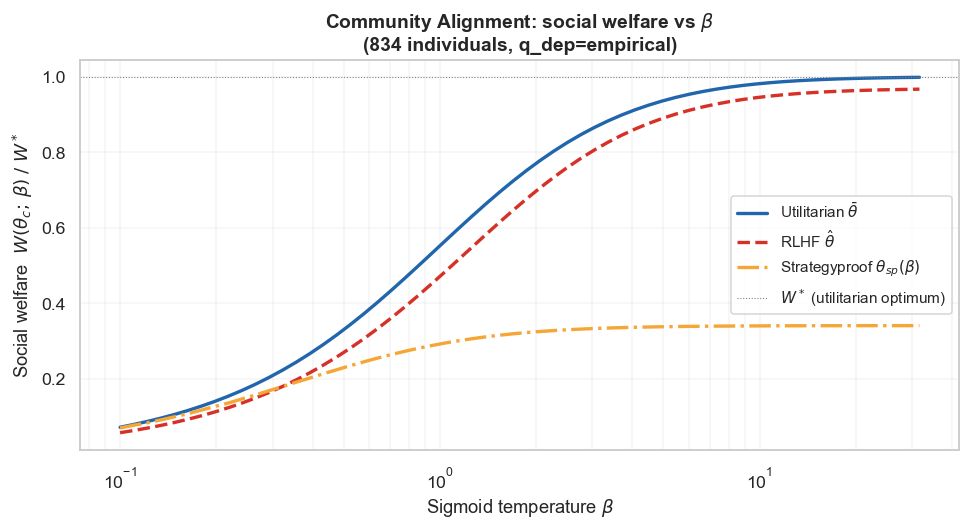


at β = 1.0:
  W_util / W*  = 0.5651
  W_rlhf / W*  = 0.4836
  W_sp   / W*  = 0.2945

at β = 31.6:
  W_util / W*  = 0.9980
  W_rlhf / W*  = 0.9666
  W_sp   / W*  = 0.3406


In [92]:
# ── Social welfare vs β: utilitarian / RLHF / strategyproof ───────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(betas, W_util_social / W_star, color="#2166ac", lw=2.2, ls="-",
        label=r"Utilitarian $\bar\theta$")
ax.plot(betas, W_rlhf_social / W_star, color="#d73027", lw=2.2, ls="--",
        label=r"RLHF $\hat\theta$")
ax.plot(betas, W_sp_social / W_star,   color="#f4a736", lw=2.2, ls="-.",
        label=r"Strategyproof $\theta_{sp}(\beta)$")
ax.axhline(1.0, color="grey", lw=0.7, ls=":", label=r"$W^*$ (utilitarian optimum)")
ax.set_xscale("log")
ax.set_xlabel(r"Sigmoid temperature $\beta$", fontsize=12)
ax.set_ylabel(r"Social welfare  $W(\theta_c;\,\beta)\;/\;W^*$", fontsize=12)
ax.set_title(f"Community Alignment: social welfare vs $\\beta$\n"
             f"({N_AGENTS} individuals, q_dep=empirical)", fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()

print(f"\nat β = 1.0:")
ix = int(np.argmin(np.abs(betas - 1.0)))
print(f"  W_util / W*  = {W_util_social[ix] / W_star:.4f}")
print(f"  W_rlhf / W*  = {W_rlhf_social[ix] / W_star:.4f}")
print(f"  W_sp   / W*  = {W_sp_social[ix]   / W_star:.4f}")
print(f"\nat β = {betas[-1]:.1f}:")
print(f"  W_util / W*  = {W_util_social[-1] / W_star:.4f}")
print(f"  W_rlhf / W*  = {W_rlhf_social[-1] / W_star:.4f}")
print(f"  W_sp   / W*  = {W_sp_social[-1]   / W_star:.4f}")


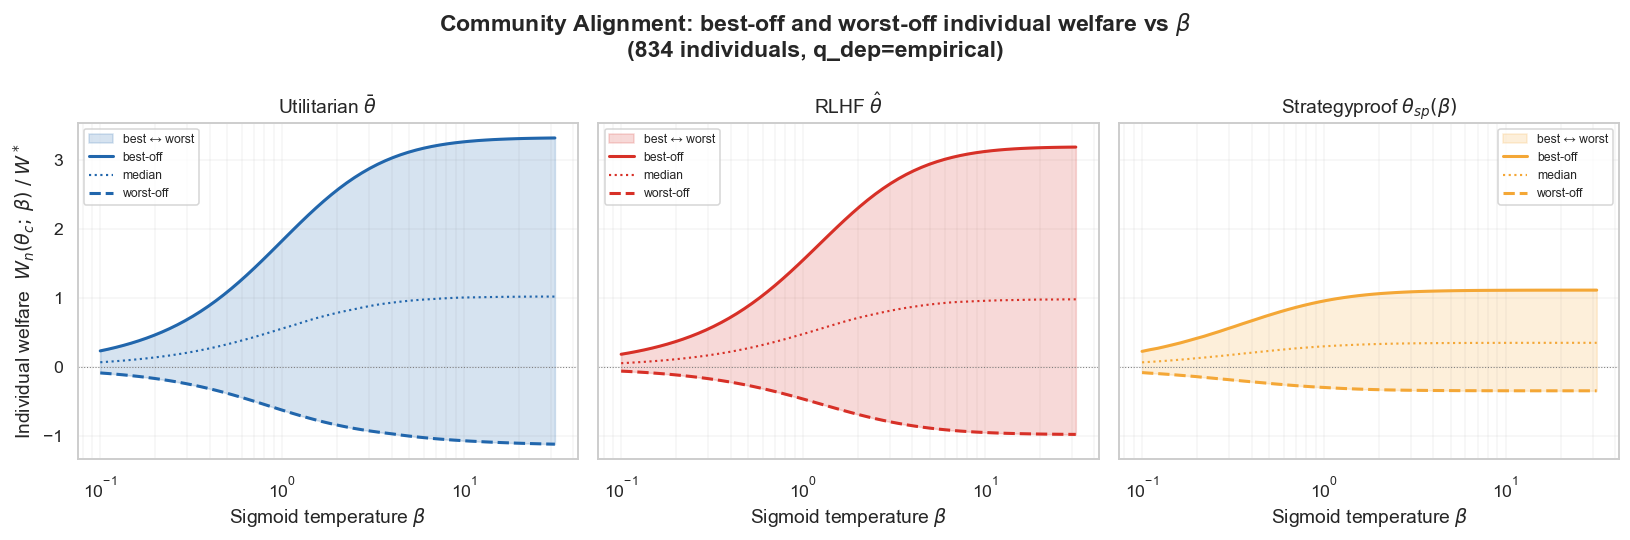

In [93]:
# ── Best-off / worst-off agent welfare per mechanism ──────────────────────
# At every β, find the agent with the highest and lowest W_n under each mechanism.
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
mech_data = [
    ("Utilitarian $\\bar\\theta$", W_util_sweep, "#2166ac"),
    ("RLHF $\\hat\\theta$",         W_rlhf_sweep, "#d73027"),
    ("Strategyproof $\\theta_{sp}(\\beta)$", W_sp_sweep,   "#f4a736"),
]
for ax, (title, W_sweep, color) in zip(axes, mech_data):
    Wn = W_sweep / W_star
    best  = Wn.max(axis=1)
    worst = Wn.min(axis=1)
    median = np.median(Wn, axis=1)
    ax.fill_between(betas, worst, best, color=color, alpha=0.18, label="best ↔ worst")
    ax.plot(betas, best,   color=color, lw=2.0, ls="-",  label="best-off")
    ax.plot(betas, median, color=color, lw=1.4, ls=":",  label="median")
    ax.plot(betas, worst,  color=color, lw=2.0, ls="--", label="worst-off")
    ax.axhline(0, color="grey", lw=0.7, ls=":")
    ax.set_xscale("log")
    ax.set_xlabel(r"Sigmoid temperature $\beta$")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, which="both", alpha=0.2)
axes[0].set_ylabel(r"Individual welfare  $W_n(\theta_c;\,\beta)\;/\;W^*$")
fig.suptitle(f"Community Alignment: best-off and worst-off individual welfare vs $\\beta$\n"
             f"({N_AGENTS} individuals, q_dep=empirical)", fontweight="bold")
plt.tight_layout()
plt.show()


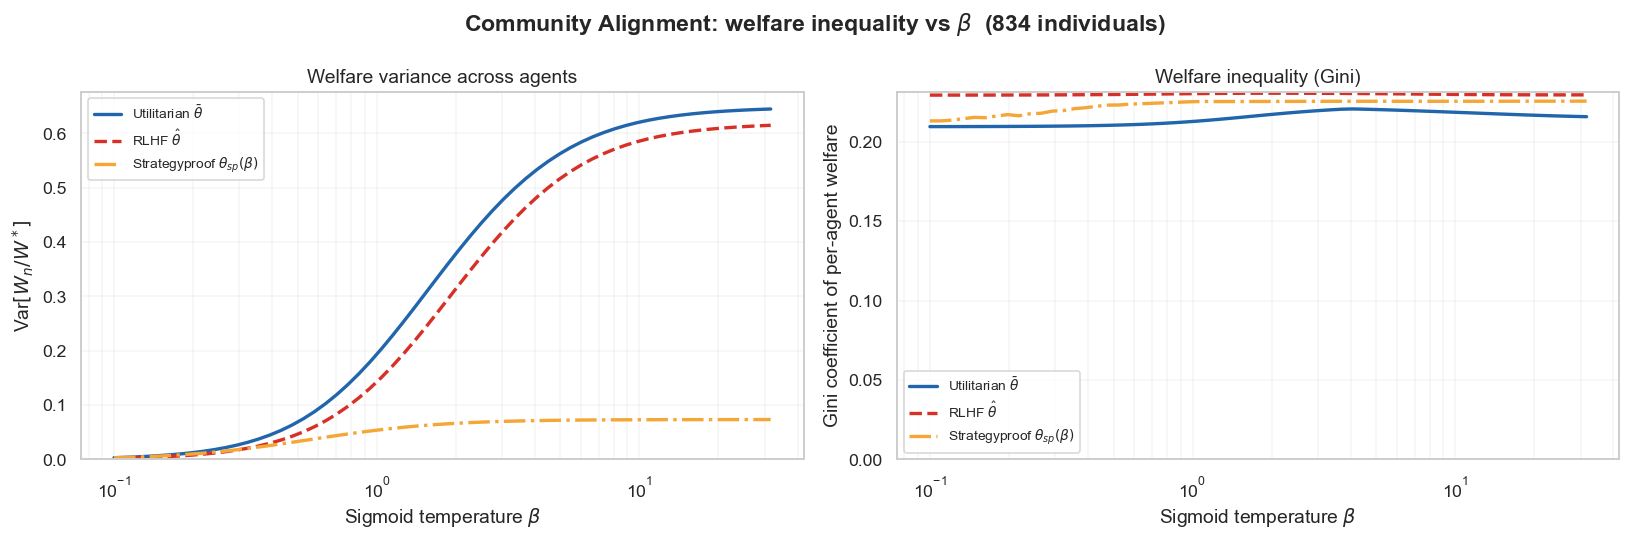


β        Var(util)   Var(rlhf)   Var(sp)   Gini(util) Gini(rlhf) Gini(sp)
 0.100    0.0032     0.0021     0.0031     0.209      0.229      0.213
 1.867    0.3600     0.2953     0.0657     0.217      0.230      0.225
31.623    0.6450     0.6150     0.0734     0.216      0.229      0.225


In [94]:
# ── Welfare inequality (variance + Gini) vs β ─────────────────────────────
def gini_coef(values: np.ndarray) -> float:
    v = np.asarray(values, dtype=float)
    v = v - v.min()
    if v.sum() < 1e-12:
        return 0.0
    v = np.sort(v)
    n = len(v)
    return float((2 * (np.arange(1, n + 1) * v).sum()) / (n * v.sum()) - (n + 1) / n)

W_star_sq = W_star ** 2
var_util = (W_util_sweep / np.sqrt(W_star_sq)).var(axis=1)
var_rlhf = (W_rlhf_sweep / np.sqrt(W_star_sq)).var(axis=1)
var_sp   = (W_sp_sweep   / np.sqrt(W_star_sq)).var(axis=1)

gini_util = np.array([gini_coef(W_util_sweep[i]) for i in range(len(betas))])
gini_rlhf = np.array([gini_coef(W_rlhf_sweep[i]) for i in range(len(betas))])
gini_sp   = np.array([gini_coef(W_sp_sweep[i])   for i in range(len(betas))])

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

ax = axes[0]
ax.plot(betas, var_util, color="#2166ac", lw=2.2, ls="-",  label=r"Utilitarian $\bar\theta$")
ax.plot(betas, var_rlhf, color="#d73027", lw=2.2, ls="--", label=r"RLHF $\hat\theta$")
ax.plot(betas, var_sp,   color="#f4a736", lw=2.2, ls="-.", label=r"Strategyproof $\theta_{sp}(\beta)$")
ax.set_xscale("log")
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Sigmoid temperature $\beta$")
ax.set_ylabel(r"Var$[W_n / W^*]$")
ax.set_title("Welfare variance across agents")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.2)

ax = axes[1]
ax.plot(betas, gini_util, color="#2166ac", lw=2.2, ls="-",  label=r"Utilitarian $\bar\theta$")
ax.plot(betas, gini_rlhf, color="#d73027", lw=2.2, ls="--", label=r"RLHF $\hat\theta$")
ax.plot(betas, gini_sp,   color="#f4a736", lw=2.2, ls="-.", label=r"Strategyproof $\theta_{sp}(\beta)$")
ax.set_xscale("log")
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Sigmoid temperature $\beta$")
ax.set_ylabel("Gini coefficient of per-agent welfare")
ax.set_title("Welfare inequality (Gini)")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.2)

fig.suptitle(f"Community Alignment: welfare inequality vs $\\beta$  ({N_AGENTS} individuals)",
             fontweight="bold")
plt.tight_layout()
plt.show()

print("\nβ        Var(util)   Var(rlhf)   Var(sp)   Gini(util) Gini(rlhf) Gini(sp)")
for b, v_u, v_r, v_s, g_u, g_r, g_s in zip(
    [betas[0], betas[len(betas) // 2], betas[-1]],
    [var_util[0], var_util[len(betas) // 2], var_util[-1]],
    [var_rlhf[0], var_rlhf[len(betas) // 2], var_rlhf[-1]],
    [var_sp[0],   var_sp[len(betas) // 2],   var_sp[-1]],
    [gini_util[0], gini_util[len(betas) // 2], gini_util[-1]],
    [gini_rlhf[0], gini_rlhf[len(betas) // 2], gini_rlhf[-1]],
    [gini_sp[0],   gini_sp[len(betas) // 2],   gini_sp[-1]],
):
    print(f"{b:6.3f}    {v_u:.4f}     {v_r:.4f}     {v_s:.4f}     {g_u:.3f}      {g_r:.3f}      {g_s:.3f}")


## 9. Save artefacts (optional)

Persist the per-user θ_n, cluster labels, welfare table, and (if section 8 was run) the β-sweep arrays for downstream use.

In [95]:
OUT_DIR = Path("empirics_communityalignment/final_layer_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

user_theta_df = pd.DataFrame(profiles, columns=FEATURE_COLS)
user_theta_df.insert(0, "cluster", labels)
user_theta_df.insert(0, "annotator_id", user_ids)
user_theta_df.to_parquet(OUT_DIR / "user_theta_clusters.parquet", index=False)

ext["welfare_df"].to_parquet(OUT_DIR / "welfare_empirical.parquet", index=False)
results["bootstrap"]["welfare_df"].to_parquet(OUT_DIR / "welfare_bootstrap.parquet", index=False)

print(f"saved to {OUT_DIR}/:")
for p in OUT_DIR.iterdir():
    print(f"  {p.name}")

saved to empirics_communityalignment/final_layer_out/:
  welfare_empirical.parquet
  welfare_bootstrap.parquet
  user_theta_clusters.parquet
